# 04 · Downstream Analytics

From ``M`` imputed histories, produce:

1. Multiple covariance estimators (EM, Rubin combined, Ledoit-Wolf,
   Marchenko-Pastur denoised)
2. Uncertainty sets (ellipsoidal and box) for robust optimisation
3. Portfolio-risk distribution for an equal-weight allocation
4. Backtest fan charts across 4 strategies
5. Copula-based scenario simulation

In [1]:
# --- preamble ----------------------------------------------------------
%matplotlib inline
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.precision", 4)
pd.set_option("display.width", 120)

# Path to Tier 2 synthetic data (relative to this notebook)
TIER2_DIR = Path.cwd().parent.parent / "synthetic_data_generator" / "output" / "tier2"
TIER2_CSV = TIER2_DIR / "returns.csv"
TIER2_COMPLETE = TIER2_DIR / "returns_complete.csv"
TIER2_GT = TIER2_DIR / "ground_truth.json"
assert TIER2_CSV.exists(), f"Tier 2 fixture missing: {TIER2_CSV}"

In [2]:
from backcast.data.loader import load_backcast_dataset
from backcast.imputation.multiple_impute import multiple_impute_regime
from backcast.models.em_stambaugh import em_stambaugh
from backcast.models.regime_hmm import compute_regime_params, fit_regime_hmm

ds = load_backcast_dataset(TIER2_CSV)
em = em_stambaugh(ds.returns_full, max_iter=500, tolerance=1e-8,
                   track_loglikelihood=False)
hmm = fit_regime_hmm(ds.returns_full[ds.long_assets], n_regimes=2, seed=0)

## Multiple imputation (regime-conditional, M=50)

In [3]:
overlap_labels = hmm.regime_labels[-ds.overlap_length:]
regime_params = compute_regime_params(ds.overlap_matrix, overlap_labels)
mi = multiple_impute_regime(
    ds, hmm.regime_labels, regime_params,
    n_imputations=50, seed=42,
)
print(f"Drew {mi.n_imputations} imputations — method={mi.method}")

Drew 50 imputations — method=regime_conditional


## Covariance comparison

In [4]:
from backcast.downstream.covariance import (
    combined_covariance, denoise_covariance, from_em_result, shrink_covariance,
)

cov_em = from_em_result(em)
cov_comb = combined_covariance(mi.imputations)
cov_shrunk = shrink_covariance(mi.imputations[0])
cov_denoised = denoise_covariance(mi.imputations[0])

table = pd.DataFrame({
    "method": ["EM direct", "Rubin combined", cov_shrunk.method, cov_denoised.method],
    "condition_number": [
        cov_em.condition_number, cov_comb.condition_number,
        cov_shrunk.condition_number, cov_denoised.condition_number,
    ],
    "min_eig": [
        cov_em.eigenvalues[-1], cov_comb.eigenvalues[-1],
        cov_shrunk.eigenvalues[-1], cov_denoised.eigenvalues[-1],
    ],
    "max_eig": [
        cov_em.eigenvalues[0], cov_comb.eigenvalues[0],
        cov_shrunk.eigenvalues[0], cov_denoised.eigenvalues[0],
    ],
})
table.round(6)

,method,condition_number,min_eig,max_eig
0,EM direct,3115.3144,3.0000e-06,0.0090
1,Rubin combined,3142.5365,3.0000e-06,0.0091
2,ledoit_wolf(α=0.001),1841.0468,5.0000e-06,0.0090
3,marchenko_pastur(q=0.002),2320.8062,4.0000e-06,0.0093


### Eigenvalue spectrum vs Marchenko-Pastur bounds

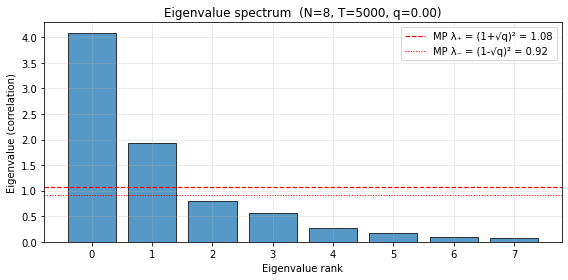

In [5]:
from backcast.visualization.plots import plot_eigenvalue_spectrum
fig = plot_eigenvalue_spectrum(cov_comb.covariance, T=len(ds.returns_full))
plt.show()

### Rubin within / between / total variance of the Σ entries

How much of each covariance element's variance is driven by
between-imputation uncertainty (i.e., missing information)?

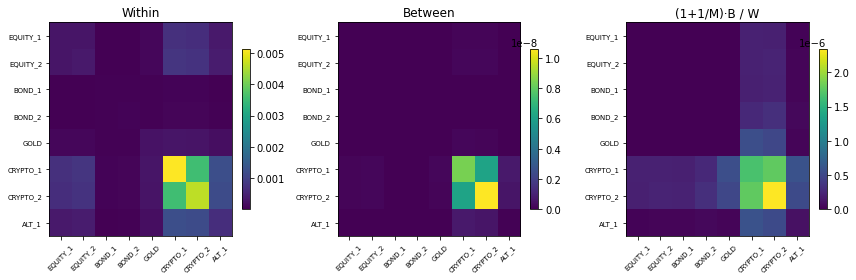

In [6]:
within = cov_comb.within_variance
between = cov_comb.between_variance
total = cov_comb.total_variance
rel_incr = (1 + 1/cov_comb.n_imputations) * between / np.where(within > 0, within, 1e-30)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, mat, title in zip(axes, [within, between, rel_incr],
                          ["Within", "Between", "(1+1/M)·B / W"]):
    im = ax.imshow(mat, cmap="viridis", aspect="auto")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.04)
    ax.set_xticks(range(mat.shape[1]))
    ax.set_xticklabels(ds.returns_full.columns, rotation=45, fontsize=7)
    ax.set_yticks(range(mat.shape[0]))
    ax.set_yticklabels(ds.returns_full.columns, fontsize=7)
plt.tight_layout()
plt.show()

## Uncertainty sets

In [7]:
from backcast.downstream.uncertainty import (
    box_uncertainty, ellipsoidal_uncertainty, portfolio_risk_distribution,
)
from backcast.visualization.plots import plot_uncertainty_ellipses

ellipse = ellipsoidal_uncertainty(mi.imputations, confidence=0.95)
box = box_uncertainty(mi.imputations, confidence=0.95)

print(f"Ellipsoid κ = {ellipse.kappa:.2f}   (confidence = {ellipse.confidence:.0%})")
print(f"μ_center = {ellipse.mu_center}")
print("\nBox uncertainty on μ:")
mu_box = pd.DataFrame({"lower": box.mu_lower, "upper": box.mu_upper},
                       index=ds.returns_full.columns)
mu_box.round(5)

Ellipsoid κ = 3.94   (confidence = 95%)
μ_center = [-1.26629747e-04 -1.12542013e-04  1.56543533e-04  2.36703721e-04
  4.31012667e-05  8.08688274e-04 -3.13857328e-04 -3.63854548e-04]

Box uncertainty on μ:


,lower,upper
EQUITY_1,-1.3000e-04,-1.3000e-04
EQUITY_2,-1.1000e-04,-1.1000e-04
BOND_1,1.6000e-04,1.6000e-04
BOND_2,2.4000e-04,2.4000e-04
GOLD,4.0000e-05,4.0000e-05
CRYPTO_1,-4.1000e-04,1.9000e-03
CRYPTO_2,-1.3300e-03,7.6000e-04
ALT_1,-7.1000e-04,3.0000e-05


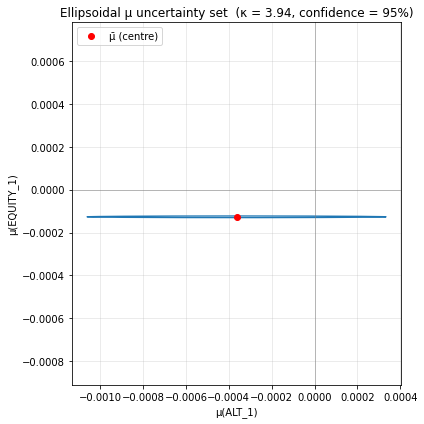

In [8]:
fig = plot_uncertainty_ellipses(ellipse, pair=(ds.short_assets[0], ds.long_assets[0]))
plt.show()

## Equal-weight portfolio-risk distribution

Annualized portfolio vol (%):
  median  : 36.69
  5-95%   : [36.24, 37.05]


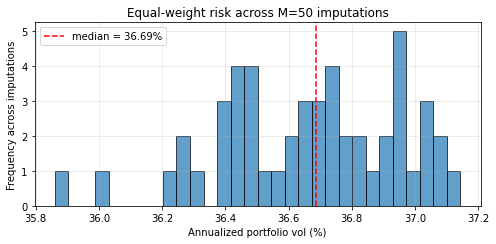

In [9]:
N = ds.n_total
w_eq = np.full(N, 1.0 / N)
risk_dist = portfolio_risk_distribution(w_eq, mi.imputations)
annualiser = np.sqrt(252) * 100
print(f"Annualized portfolio vol (%):")
print(f"  median  : {risk_dist.median_risk * annualiser:.2f}")
print(f"  5-95%   : [{risk_dist.percentile_5 * annualiser:.2f}, "
      f"{risk_dist.percentile_95 * annualiser:.2f}]")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(risk_dist.portfolio_risks * annualiser, bins=30, edgecolor="k", alpha=0.7)
ax.axvline(risk_dist.median_risk * annualiser, color="r", lw=1.5, ls="--",
           label=f"median = {risk_dist.median_risk * annualiser:.2f}%")
ax.set_xlabel("Annualized portfolio vol (%)")
ax.set_ylabel("Frequency across imputations")
ax.set_title(f"Equal-weight risk across M={mi.n_imputations} imputations")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Backtests — 4 strategies

In [10]:
from backcast.downstream.backtest import run_backtest
from backcast.visualization.plots import plot_backtest_fan

backtests = {}
for strat in ("equal_weight", "inverse_volatility", "min_variance", "risk_parity"):
    backtests[strat] = run_backtest(
        mi.imputations, strategy=strat,
        lookback=63, rebalance_freq=21,
    )

summary = pd.DataFrame({
    strat: {
        "sharpe_median": np.median(bt.sharpe_distribution),
        "sharpe_p05": np.percentile(bt.sharpe_distribution, 5),
        "sharpe_p95": np.percentile(bt.sharpe_distribution, 95),
        "mdd_median": np.median(bt.max_drawdown_distribution),
        "total_return_median": np.median(bt.total_return_distribution),
    }
    for strat, bt in backtests.items()
}).T
summary.round(3)

,sharpe_median,sharpe_p05,sharpe_p95,mdd_median,total_return_median
equal_weight,0.013,-0.132,0.181,-0.853,-0.710
inverse_volatility,0.111,0.034,0.208,-0.447,0.109
min_variance,0.124,0.010,0.242,-0.288,0.139
risk_parity,0.069,-0.035,0.199,-0.578,-0.128


### Fan charts

Each panel shows the median cumulative path and the 5–95 % band across
the M imputed histories.

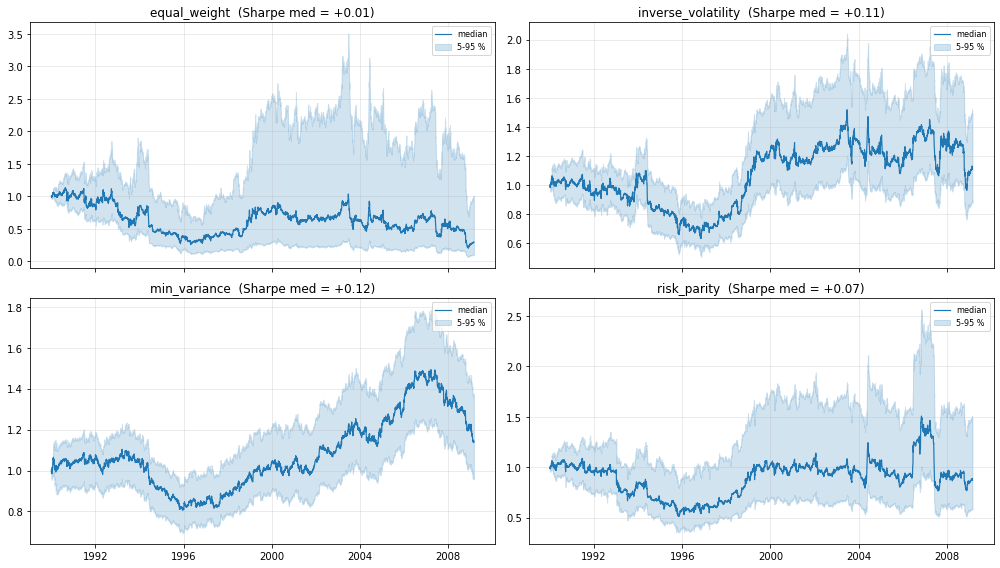

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for ax, (strat, bt) in zip(axes.flat, backtests.items()):
    idx = bt.cumulative_median.index
    ax.plot(idx, bt.cumulative_median.values, "C0-", lw=1.2, label="median")
    ax.fill_between(idx, bt.cumulative_p05, bt.cumulative_p95,
                    color="C0", alpha=0.2, label="5-95 %")
    ax.set_title(f"{strat}  (Sharpe med = "
                 f"{np.median(bt.sharpe_distribution):+.2f})")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Copula-based simulation

In [12]:
from backcast.imputation.copula_sim import fit_copula, fit_marginals, simulate_copula
from backcast.imputation.single_impute import single_impute

filled = single_impute(ds, em)
marg = fit_marginals(filled, candidates=("normal", "student_t"))
print("Selected marginal per asset:")
for name, mf in marg.items():
    extra = f"(df={mf.params['df']:.1f})" if mf.distribution == "student_t" else ""
    print(f"  {name:10s}  {mf.distribution}  {extra}")

Selected marginal per asset:
  EQUITY_1    student_t  (df=3.5)
  EQUITY_2    student_t  (df=3.6)
  BOND_1      student_t  (df=4.1)
  BOND_2      student_t  (df=4.1)
  GOLD        student_t  (df=3.6)
  CRYPTO_1    student_t  (df=3.0)
  CRYPTO_2    student_t  (df=2.7)
  ALT_1       student_t  (df=3.1)


In [13]:
cop_t = fit_copula(filled, marg, copula_type="student_t")
print(f"Student-t copula ν = {cop_t.df:.1f}")
print(f"Copula correlation (off-diagonal max |ρ|) = "
      f"{np.max(np.abs(cop_t.correlation - np.eye(cop_t.correlation.shape[0]))):.3f}")

sim = simulate_copula(cop_t, marg, n_simulations=500, horizon=252, seed=7)
print(f"Simulated scenarios shape: {sim.simulated_returns.shape}")

Student-t copula ν = 3.0
Copula correlation (off-diagonal max |ρ|) = 0.895


Simulated scenarios shape: (500, 252, 8)


### Marginal reconstruction check

The simulated per-asset distribution should line up with the fitted
marginal.  Here we overlay the density of 500 × 252 simulated draws
against the historical imputed returns.

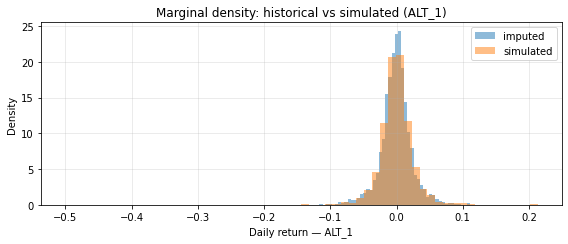

In [14]:
asset = ds.short_assets[0]
asset_idx = sim.asset_names.index(asset)
sim_flat = sim.simulated_returns[:, :, asset_idx].ravel()

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(filled[asset], bins=60, density=True, alpha=0.5, label="imputed")
ax.hist(sim_flat[::50], bins=60, density=True, alpha=0.5, label="simulated")
ax.set_xlabel(f"Daily return — {asset}")
ax.set_ylabel("Density")
ax.set_title(f"Marginal density: historical vs simulated ({asset})")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

- Rubin-combined covariance carries **within**, **between**, and **total**
  variance components — the between term quantifies imputation-driven
  uncertainty per covariance entry.
- Ledoit-Wolf and Marchenko-Pastur both reduce the condition number vs
  the naive sample covariance.
- The ellipsoidal μ-uncertainty set is directly consumable by robust
  optimisers (`cvxpy`, `scipy.optimize`, etc.).
- Running each strategy across M imputations yields a **distribution**
  of Sharpe / MDD / total return, not a single point — this is the
  actionable downstream output.
- Copula simulation extends the history forward while preserving both
  marginal tails and joint dependence.